# SBI for Solar System Acceleration from Quaia Quasar Proper Motions

**Pipeline:**
1. Prior: θ = {alm for ℓ ≤ 3 (30 params), Cℓ for ℓ = 4–10 (7 params)} → 37-dim
2. Forward model: synthesize noisy HEALPix PM maps → VSH fit (lmax=10) → summary x (240-dim)
3. SNPE on 5000 (θ, x) pairs → posterior over θ conditioned on real Quaia summary
4. Extract (gx, gy, gz) from the l=1 dipole of posterior samples

**Key speedup:** The normal matrix M = Aᵀ C⁻¹ A is precomputed once (same noise maps
every simulation). Each simulation then only needs one `map2alm_spin` call + a cheap LU solve.

In [1]:
import numpy as np
import healpy as hp
import math
import matplotlib.pyplot as plt
import corner
import torch
from scipy.linalg import lu_factor, lu_solve
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.table as at
import pandas as pd
from astropy.io import fits

from sbi.inference import SNPE
from sbi import utils as utils
from sbi.utils.user_input_checks import check_sbi_inputs, process_prior, process_simulator
from sbi.inference import simulate_for_sbi
from astropy.table import join 

from sbi_hpm.geometry import SkyFunction
from sbi_hpm.pixelization import Pixelize, pixelize_full_covariance
from sbi_hpm.data import load_gaia_qso, compute_pixel_stats, make_galactic_mask
from sbi_hpm.forward_model import WeightedSHT
from sbi_hpm.sbi_setup import (
    n_real_params, build_full_alm_complex, build_det_alm_complex,
    precompute_noise_cholesky, generate_pixel_noise,
    create_prior_full, create_prior_det,
    simulator_full, simulator_det,
)
from sbi_hpm.diagnostics import marginal_coverage, run_tarp_test, extract_g_tarp, extract_g_theta
from sbi_hpm import plotting

import matplotlib as mpl

mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Liberation Serif'],
    'text.latex.preamble': r'\usepackage{newtxtext}\usepackage{newtxmath}',
})

/home/phuy2808/Astrophysis/Intern_apc/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Quaia Data and Compute Pixel Statistics
*(Same preprocessing as quaia.ipynb)*

In [2]:
#path = r'/home/phuy2808/Astrophysis/Intern_apc/quaia_G20.0_with_pmra_pmdec_corr.csv'
path = r'/home/phuy2808/Astrophysis/Intern_apc/gaia_qso_edata_5_params.csv'

In [3]:
quaia = load_gaia_qso(path)
gaia  = load_gaia_qso('../gaia_qso_edata_5_params.csv')

table = quaia


ra    = table['ra'].values
dec   = table['dec'].values
pmra  = table['pmra'].values
pmdec = table['pmdec'].values
sig_pmra  = table['pmra_error'].values
sig_pmdec = table['pmdec_error'].values
pm_corr   = table['pmra_pmdec_corr'].values
#z = table['redshift_quaia'].values

print(f"Sources after cuts: {len(ra):,}")

Sources after cuts: 1,215,942


In [4]:
# redshift_map = dict(zip(np.array(table_quaia['source_id']),
#                         np.array(table_quaia['redshift_quaia'])))
# # 5 equal-count redshift bins (quantile binning)
# N_BINS = 5
# table['z_bin'], z_bin_edges = pd.qcut(
#     table['redshift_quaia'], q=N_BINS, labels=False, retbins=True
# )
# z_bin     = table['z_bin'].values

# #ibin goes from 0 to 4
# mask_z = z_bin == 4
# ra    = table['ra'].values[mask_z]
# dec   = table['dec'].values[mask_z]
# pmra  = table['pmra'].values[mask_z]
# pmdec = table['pmdec'].values[mask_z]
# sig_pmra  = table['pmra_error'].values[mask_z]
# sig_pmdec = table['pmdec_error'].values[mask_z]
# pm_corr   = table['pmra_pmdec_corr'].values [mask_z]
# z = table['redshift_quaia'].values[mask_z]

In [5]:
# pixelize_full_covariance now imported from sbi_hpm.pixelization
nside = 64
npix = hp.nside2npix(nside)

pixelize_data = compute_pixel_stats(ra, dec,
    pmra, pmdec, sig_pmra, sig_pmdec, pm_corr, nside = nside, galcut = 0
)  

quaia_pmra_wm, quaia_pmdec_wm, quaia_sig_pmra_wm, quaia_sig_pmdec_wm, quaia_pm_corr_wm = pixelize_data['pmra_wm'], pixelize_data['pmdec_wm'], pixelize_data['sig_pmra_wm'], pixelize_data['sig_pmdec_wm'], pixelize_data['pm_corr_wm']
mask_quaia = pixelize_data['mask']

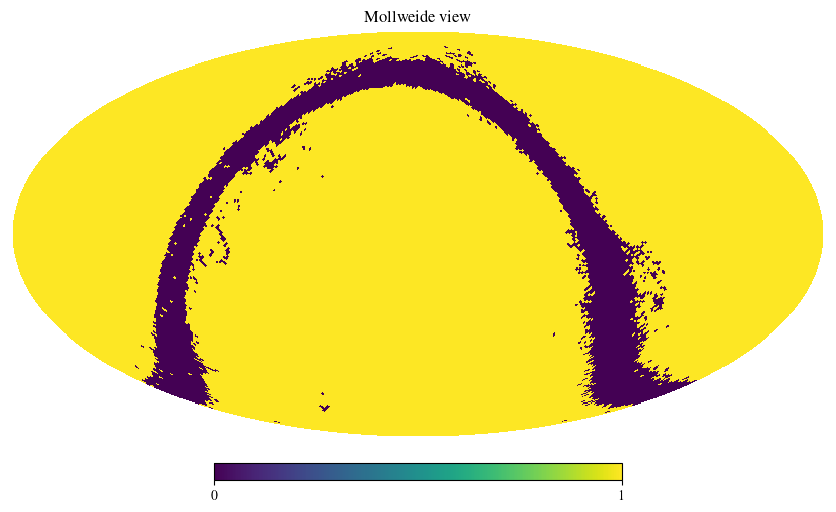

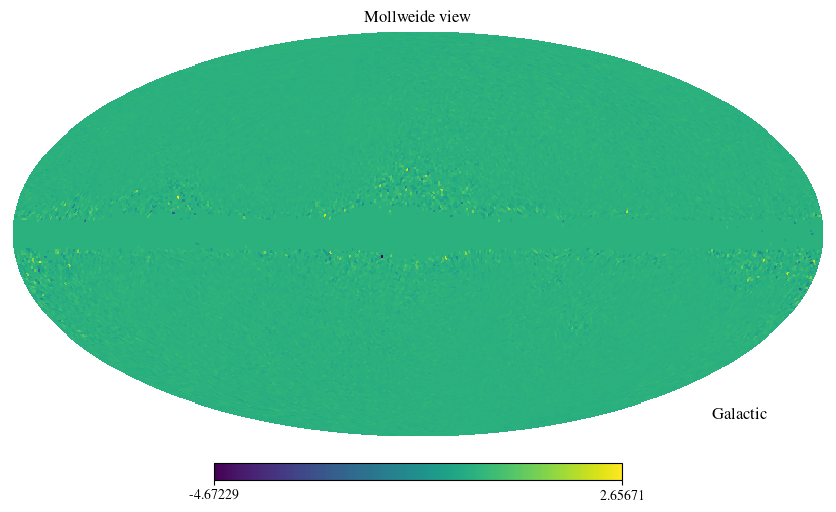

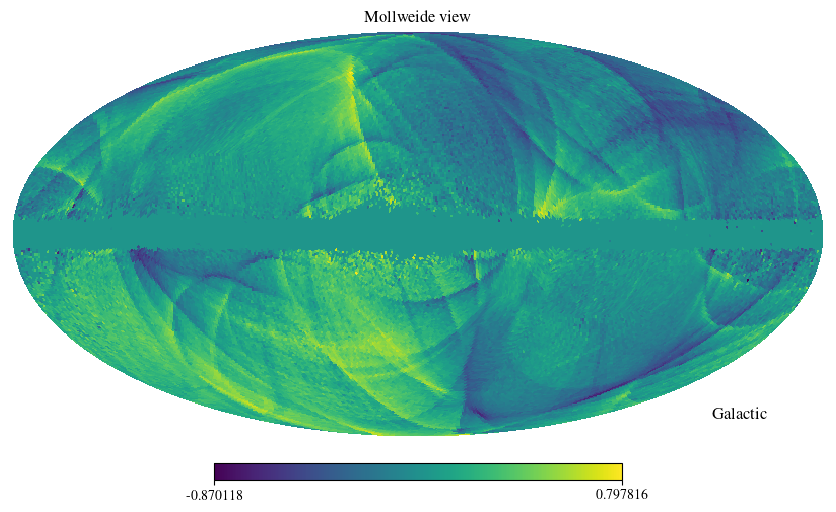

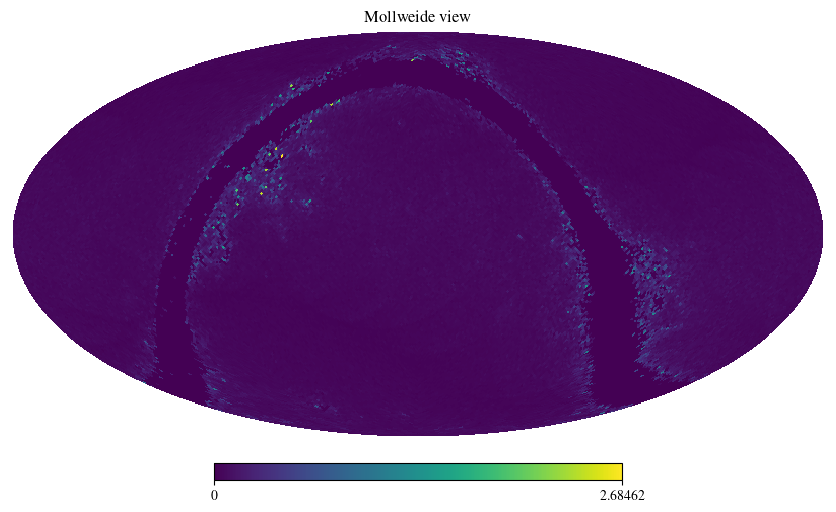

In [6]:
hp.mollview(mask_quaia)
hp.mollview(quaia_pmra_wm*mask_quaia, coord=['C', 'G'])
hp.mollview(quaia_pm_corr_wm, coord=['C', 'G'])
hp.mollview(quaia_sig_pmra_wm)
#hp.mollview(z_wm)

## 2. SBI Dimensions and Prior

| Block | Content | Size |
|-------|---------|------|
| θ[:30] | alm (E+B) for ℓ = 1, 2, 3 | 30 |
| θ[30:] | Cℓ for ℓ = 4 … 10 (shared E/B) | 7 |
| **θ total** | | **37** |
| x | best-fit alm (lmax=10 VSH fit) | 240 |

In [7]:
lmax_sig = 3  # ℓ ≤ 3  : deterministic signal parameters in θ
lmax_fit = 10  # ℓ ≤ 10 : VSH fit used as summary statistic x

# n_real_params now imported from sbi_hpm.sbi_setup

n_alm_l3  = n_real_params(lmax_sig)        # 30
n_Cl      = 2 * (lmax_fit - lmax_sig)      # 14  (Cl_E[4..10] + Cl_B[4..10])
n_theta   = n_alm_l3 + n_Cl               # 44
n_summary = n_real_params(lmax_fit)        # 240

# Deterministic-only model: no stochastic Cl — θ = alm for ℓ ≤ 3 only
n_theta_det = n_alm_l3   # 30

print(f"θ dimension (full model) : {n_theta}  ({n_alm_l3} alm_l−3  +  {n_Cl} Cl_4..10 [E & B separate])")
print(f"θ dimension (det. only)  : {n_theta_det}  (alm_l−3 only, no stochastic modes)")
print(f"Summary dimension        : {n_summary}")

θ dimension (full model) : 44  (30 alm_l−3  +  14 Cl_4..10 [E & B separate])
θ dimension (det. only)  : 30  (alm_l−3 only, no stochastic modes)
Summary dimension        : 240


In [8]:
# Units: all internal values in mas/yr
# alm  ∈ [-20, +20] µas/yr  →  [-0.020, +0.020] mas/yr
# Cl   ∈ [  0,  40] µas²/yr²  →  [0, 4e-5] (mas/yr)²

alm_bound = 60e-3   # mas/yr
Cl_bound  = 60e-6   # (mas/yr)²

# Full model: θ = [alm_l≤3 (30), Cl_E_4..10 (7), Cl_B_4..10 (7)]
low_full  = torch.cat([-alm_bound * torch.ones(n_alm_l3),
                        torch.zeros(n_Cl)])
high_full = torch.cat([ alm_bound * torch.ones(n_alm_l3),
                        Cl_bound  * torch.ones(n_Cl)])
prior_full = utils.BoxUniform(low=low_full, high=high_full)

# Deterministic-only model: θ = [alm_l≤3 (30)]  — no Cl parameters
low_det  = -alm_bound * torch.ones(n_theta_det)
high_det =  alm_bound * torch.ones(n_theta_det)
prior_det = utils.BoxUniform(low=low_det, high=high_det)

print(f"prior_full : θ ∈ R^{n_theta}  (alm + Cl_E + Cl_B)")
print(f"prior_det  : θ ∈ R^{n_theta_det}  (alm only)")

prior_full : θ ∈ R^44  (alm + Cl_E + Cl_B)
prior_det  : θ ∈ R^30  (alm only)


## 3. Precompute Normal Matrix (one-time cost)

The normal matrix **M = Aᵀ C⁻¹ A** depends only on the noise maps and sky mask,
not on the data.  We build it once (240 `matvec` calls) and cache its LU factorisation.

**Per-simulation cost then reduces to:**  
1 × `map2alm_spin` (adjoint)  →  `lu_solve`  (trivial) — instead of rebuilding the full solve.

In [9]:
# Replace non-finite noise values with 0 so they get zero weight in C⁻¹
sig_pmra_safe  = np.where(np.isfinite(quaia_sig_pmra_wm),  quaia_sig_pmra_wm,  0.0)
sig_pmdec_safe = np.where(np.isfinite(quaia_sig_pmdec_wm), quaia_sig_pmdec_wm, 0.0)
pm_corr_safe   = np.nan_to_num(quaia_pm_corr_wm, nan=0.0)

base_solver = WeightedSHT(
    nside, mask_quaia,
    quaia_pmra_wm,  quaia_pmdec_wm,
    sig_pmra_safe,  sig_pmdec_safe,  pm_corr_safe
)

In [10]:
# Build and cache LU factorisations in WeightedSHT for fast repeated solves
base_solver.build_lu(lmax_fit)   # 240×240 — full model
base_solver.build_lu(lmax_sig)   #  30×30  — det. model

# Thin wrapper: delegates to base_solver.solve_fast using its cached LU
solve_fast = lambda pmra, pmdec, lmax=lmax_fit: base_solver.solve_fast(pmra, pmdec, lmax)

## 4. Forward-model Helpers

In [11]:
# build_full_alm_complex, build_det_alm_complex now imported from sbi_hpm.sbi_setup
# draw_cl_alm_complex is an internal helper used by those functions

In [12]:
# Pre-compute per-pixel Cholesky factors using sbi_hpm
L11, L21, L22, valid_pix = precompute_noise_cholesky(
    sig_pmra_safe, sig_pmdec_safe, pm_corr_safe, mask_quaia, npix
)
print(f"Valid pixels for noise: {valid_pix.sum()}")

Valid pixels for noise: 43182


## 5. Simulator

```
θ  →  full alm (det. l≤3  +  random l=4..10)
   →  alm2map_spin   →  pmra_sim, pmdec_sim  (full sky)
   →  + correlated pixel noise
   →  apply mask  (implicit in C⁻¹ = 0 outside mask)
   →  solve_fast  (map2alm_spin + lu_solve)
   →  x  (240-dim summary)
```

## 6. Real-Data Summary Statistic

Apply the same `solve_fast` to the real Quaia pixel maps to get **x_obs** (240-dim).

In [13]:
best_fit_l10 = base_solver.solve_fast(quaia_pmra_wm, quaia_pmdec_wm, lmax_fit)
best_fit_l3  = base_solver.solve_fast(quaia_pmra_wm, quaia_pmdec_wm, lmax_sig)

x_obs     = torch.tensor(best_fit_l10, dtype=torch.float32)
x_obs_l3 = torch.tensor(best_fit_l3, dtype=torch.float32)

# Quick sanity check: compare dipole to s2g
skyfunc = SkyFunction(nside = nside)
g_map = skyfunc.s2g(best_fit_l10[[0, lmax_fit, lmax_fit + 1]] * 1e3)
print(f"Real-data dipole (from solve_fast):")
print(f"  gx = {g_map[0]:.2f}  gy = {g_map[1]:.2f}  gz = {g_map[2]:.2f}  µas/yr")
print(f"  |g| = {np.linalg.norm(g_map):.2f} µas/yr")

Real-data dipole (from solve_fast):
  gx = 0.43  gy = -4.43  gz = -2.45  µas/yr
  |g| = 5.08 µas/yr


## 7. Run Simulations (5000)

Each simulation costs ≈ 1 `map2alm_spin` + 1 `lu_solve` (240×240) — typically < 50 ms.
Total ≈ 5 min on a single core.

In [14]:
n_simulations = 10000

# Wrappers: simulator_full returns (tensor, pmra, pmdec) → take [0]
#           simulator_det  returns tensor directly          → pass through
import functools

_sim_full = functools.partial(
    simulator_full,
    solver=base_solver, L11=L11, L21=L21, L22=L22,
    valid_pix=valid_pix, npix=npix,
    lmax_sig=lmax_sig, lmax_fit=lmax_fit,
    n_alm_l3=n_alm_l3, n_Cl=n_Cl,
)
_sim_det = functools.partial(
    simulator_det,
    solver=base_solver, L11=L11, L21=L21, L22=L22,
    valid_pix=valid_pix, npix=npix,
    lmax_sig=lmax_sig, lmax_fit=lmax_fit,
    n_alm_l3=n_alm_l3,
)
sim_full_wrapped = lambda theta: _sim_full(theta)[0]
sim_det_wrapped  = lambda theta: _sim_det(theta)

# --- Full model (θ = 44-dim) ---
prior_full_proc, _, prior_full_np = process_prior(prior_full)
sim_full_proc = process_simulator(sim_full_wrapped, prior_full_proc, prior_full_np)
check_sbi_inputs(sim_full_proc, prior_full_proc)

print(f"Running {n_simulations} simulations [full model] …")
theta_sims_full, x_sims_full = simulate_for_sbi(
    sim_full_proc,
    proposal=prior_full_proc,
    num_simulations=n_simulations,
)
print(f"Full model done.  θ shape: {theta_sims_full.shape},  x shape: {x_sims_full.shape}")

# --- Deterministic-only model (θ = 30-dim) ---
prior_det_proc, _, prior_det_np = process_prior(prior_det)
sim_det_proc = process_simulator(sim_det_wrapped, prior_det_proc, prior_det_np)
check_sbi_inputs(sim_det_proc, prior_det_proc)

print(f"\nRunning {n_simulations} simulations [det. model] …")
theta_sims_det, x_sims_det = simulate_for_sbi(
    sim_det_proc,
    proposal=prior_det_proc,
    num_simulations=n_simulations,
)
print(f"Det. model done.  θ shape: {theta_sims_det.shape},  x shape: {x_sims_det.shape}")

Running 10000 simulations [full model] …


100%|██████████| 10000/10000 [03:45<00:00, 44.32it/s]


Full model done.  θ shape: torch.Size([10000, 44]),  x shape: torch.Size([10000, 240])

Running 10000 simulations [det. model] …


100%|██████████| 10000/10000 [03:51<00:00, 43.11it/s]


Det. model done.  θ shape: torch.Size([10000, 30]),  x shape: torch.Size([10000, 30])


## 8. Train SNPE (Neural Posterior Estimation)

In [15]:
# --- Full model ---
inference_full = SNPE(prior=prior_full_proc)
inference_full = inference_full.append_simulations(theta_sims_full, x_sims_full)

print("Training neural density estimator [full model] …")
de_full = inference_full.train()
posterior_full = inference_full.build_posterior(de_full)
print(posterior_full)

# --- Deterministic-only model ---
inference_det = SNPE(prior=prior_det_proc)
inference_det = inference_det.append_simulations(theta_sims_det, x_sims_det)

print("\nTraining neural density estimator [det. model] …")
de_det = inference_det.train()
posterior_det_model = inference_det.build_posterior(de_det)
print(posterior_det_model)

Training neural density estimator [full model] …
 Neural network successfully converged after 136 epochs.Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.

Training neural density estimator [det. model] …
 Neural network successfully converged after 299 epochs.Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


## 9. Sample Posterior conditioned on Real Data

In [16]:
n_posterior = 10000

print(f"Sampling {n_posterior} draws [full model] …")
samples_full = posterior_full.sample((n_posterior,), x=x_obs)
samples_full_np = samples_full.detach().cpu().numpy()

print(f"Sampling {n_posterior} draws [det. model] …")
samples_det = posterior_det_model.sample((n_posterior,), x=x_obs_l3)
samples_det_np = samples_det.detach().cpu().numpy()

print(f"Full model posterior  : {samples_full_np.shape}")
print(f"Det.  model posterior : {samples_det_np.shape}")

Sampling 10000 draws [full model] …


Drawing 10000 posterior samples: 10518it [00:30, 344.61it/s]                          


Sampling 10000 draws [det. model] …


Drawing 10000 posterior samples: 100%|██████████| 10000/10000 [00:04<00:00, 2376.01it/s]

Full model posterior  : (10000, 44)
Det.  model posterior : (10000, 30)


## 10. Extract (gx, gy, gz) from Posterior

The ℓ = 1 dipole sits at indices `[0, lmax_sig, lmax_sig+1]` of θ:
- `θ[0]`            = E a_{1,0}      → gz via s2g
- `θ[lmax_sig]`     = E Re(a_{1,1}) → gx via s2g
- `θ[lmax_sig + 1]` = E Im(a_{1,1}) → gy via s2g

All multiplied by 1e3 to convert mas/yr → µas/yr before applying s2g.
dipole_idx = np.array([0, lmax_sig, lmax_sig + 1])   # [0, 3, 4]


In [23]:

def extract_g(posterior_np):
    """Convert posterior samples to (gx, gy, gz) in µas/yr."""
    return np.apply_along_axis(
        lambda t: skyfunc.s2g(t[dipole_idx] * 1e3),   # mas/yr → µas/yr
        axis=1, arr=posterior_np
    )

g_full = extract_g(samples_full_np)   # shape (n_posterior, 3)
g_det  = extract_g(samples_det_np)    # shape (n_posterior, 3)

# MAP from real data
g_obs = np.array(skyfunc.s2g(best_fit_l3[dipole_idx] * 1e3))

labels = ['gx', 'gy', 'gz']
for name, g_post in [('Full model', g_full), ('Det. model', g_det)]:
    q16, q50, q84 = np.percentile(g_post, [16, 50, 84], axis=0)
    print(f"\nPosterior [{name}] (µas/yr):")
    for i, lab in enumerate(labels):
        print(f"  {lab} = {q50[i]:.2f}  +{q84[i]-q50[i]:.2f}  -{q50[i]-q16[i]:.2f}")

print(f"\nMAP from data:  gx={g_obs[0]:.2f}  gy={g_obs[1]:.2f}  gz={g_obs[2]:.2f}  µas/yr")
print(f"|g| = {np.linalg.norm(g_obs):.2f} µas/yr")


Posterior [Full model] (µas/yr):
  gx = -0.12  +1.04  -1.05
  gy = -4.61  +1.45  -1.43
  gz = -2.93  +0.69  -0.70

Posterior [Det. model] (µas/yr):
  gx = -0.33  +0.46  -0.46
  gy = -4.46  +0.40  -0.39
  gz = -3.02  +0.37  -0.37

MAP from data:  gx=-0.28  gy=-4.09  gz=-2.84  µas/yr
|g| = 4.99 µas/yr


<>:43: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\e'
<>:43: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_3844/3490796036.py:43: SyntaxWarning: invalid escape sequence '\e'
  Line2D([0], [0], color='blue',  lw=2, label='$a_{\ell m} (\ell  \leq 3) + C_{\ell}$'),
/tmp/ipykernel_3844/3490796036.py:44: SyntaxWarning: invalid escape sequence '\e'
  Line2D([0], [0], color='orange', lw=2, label='$a_{\ell m} (\ell  \leq 3)$'),


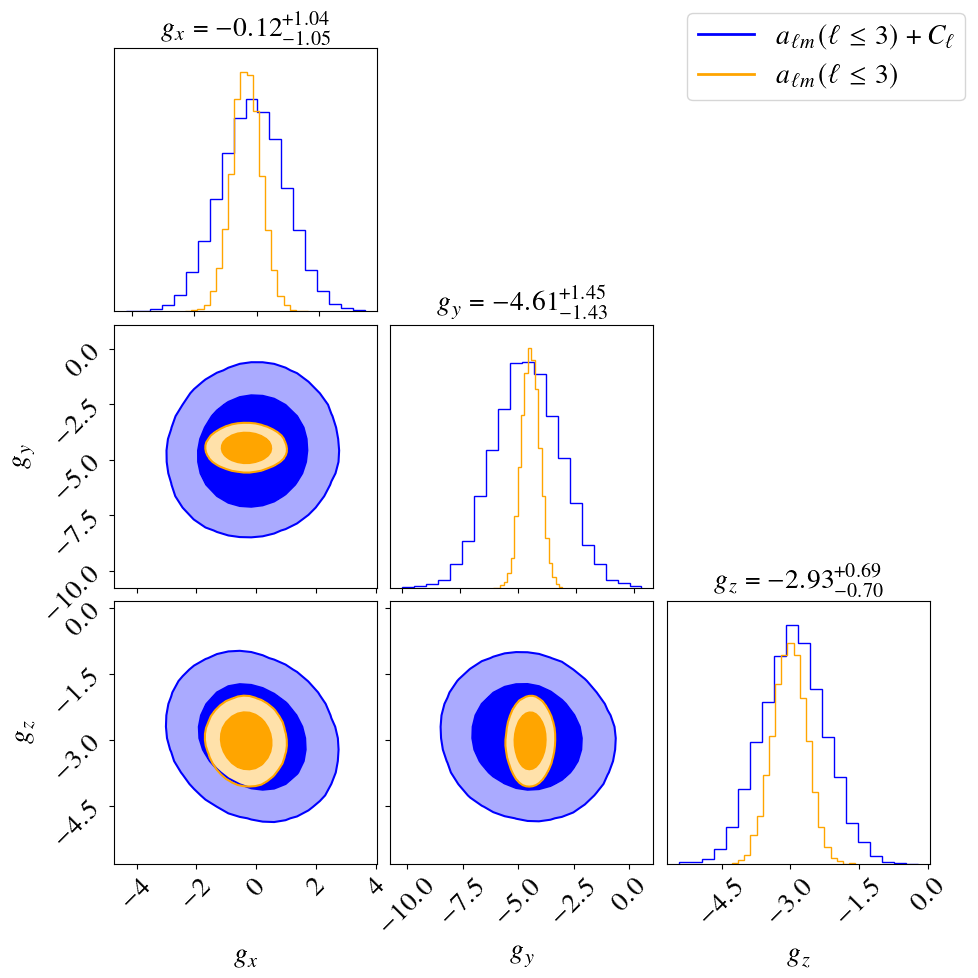

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Full model corner
corner.corner(
    g_full,
    labels=[r'$g_x$', r'$g_y$', r'$g_z$'],
    show_titles=True,
    color='blue',
    fig=fig,
    plot_datapoints=False,
    fill_contours=True,
    plot_contours=True,
    levels=[0.68, 0.95],
    hist=False,
    smooth = 1.5,
    hist2d_kwargs={'bins': 80, 'density': True},
    title_kwargs={'fontsize': 20, 'pad': 10},
    label_kwargs={'fontsize': 20},

)

# Det. model overplotted
corner.corner(
    g_det,
    labels=[r'$g_x$', r'$g_y$', r'$g_z$'],
    color='orange',
    fig=fig,
    plot_datapoints=False,
    fill_contours=True,
    plot_contours=True,
    levels=[0.68, 0.95],
    hist=False,
    smooth = 1.5,
    hist2d_kwargs={'bins': 80, 'density': True},
    label_kwargs={'fontsize': 20},
)

for ax in fig.axes:
    ax.tick_params(labelsize=20) 
    
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue',  lw=2, label='$a_{\ell m} (\ell  \leq 3) + C_{\ell}$'),
    Line2D([0], [0], color='orange', lw=2, label='$a_{\ell m} (\ell  \leq 3)$'),
    #Line2D([0], [0], color='red', lw=2, ls='--', label='MAP from data'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=20)
#plt.savefig('output/gxyz_corner_quaia.pdf', bbox_inches='tight')
plt.show()

## TARP Coverage Test

Tests whether the posterior estimator is well-calibrated using the Distance-to-Random-Point (DRP) method (Lemos, Coogan et al. 2023).  
For a calibrated posterior: **ECP(α) = 1 − α** (diagonal line).  
Deviation above diagonal = under-confident; below = over-confident.

In [17]:
import tarp

N_TARP         = 500   # test simulations
N_TARP_SAMPLES = 500   # posterior samples per test point

In [18]:
# ── TARP test simulations: full model (44-dim θ, x shape 240) ────────────────
print(f'Generating {N_TARP} TARP test simulations for full model...')

theta_tarp_full = prior_full.sample((N_TARP,))          # (N_TARP, 44)
x_tarp_full     = torch.stack([
    sim_full_wrapped(theta_tarp_full[i])
    for i in range(N_TARP)
])                                                       # (N_TARP, 240)

print(f'theta_tarp_full: {theta_tarp_full.shape}')
print(f'x_tarp_full:     {x_tarp_full.shape}')

Generating 500 TARP test simulations for full model...
theta_tarp_full: torch.Size([500, 44])
x_tarp_full:     torch.Size([500, 240])


In [19]:
# ── Posterior samples: full model ────────────────────────────────────────────
print(f'Drawing {N_TARP_SAMPLES} posterior samples for {N_TARP} test sims (full model)...')
with torch.no_grad():
    samples_tarp_full = torch.stack([
        posterior_full.sample((N_TARP_SAMPLES,), x=x_tarp_full[i])
        for i in range(N_TARP)
    ], dim=1)   # (N_TARP_SAMPLES, N_TARP, 44)
print(f'samples_tarp_full: {samples_tarp_full.shape}')

Drawing 500 posterior samples for 500 test sims (full model)...


Drawing 500 posterior samples: 664it [00:08, 75.45it/s]                        
Drawing 500 posterior samples: 674it [00:04, 151.08it/s]                       
Drawing 500 posterior samples: 724it [00:04, 167.60it/s]                       
Drawing 500 posterior samples: 615it [00:03, 164.06it/s]                        
Drawing 500 posterior samples: 707it [00:02, 241.59it/s]                         
Drawing 500 posterior samples: 713it [00:02, 248.36it/s]                         
Drawing 500 posterior samples: 506it [00:33, 15.21it/s]                         
Drawing 500 posterior samples: 760it [00:04, 161.83it/s]                        
Drawing 500 posterior samples: 605it [00:22, 26.66it/s]                         
Drawing 500 posterior samples: 722it [00:06, 116.58it/s]                        
Drawing 500 posterior samples: 543it [00:11, 47.27it/s]                        
Drawing 500 posterior samples: 765it [00:04, 188.03it/s]                       
Drawing 500 posterior samples: 

KeyboardInterrupt: 

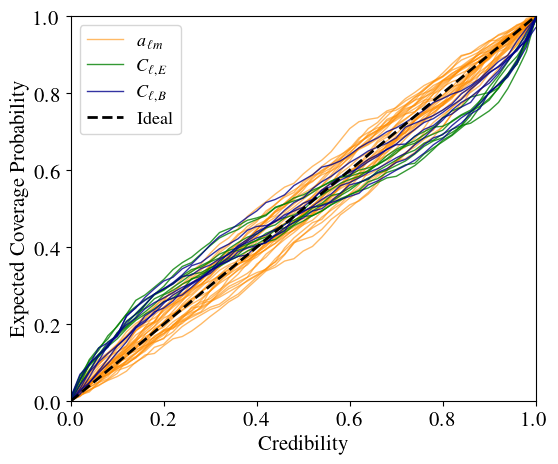

In [ ]:
# marginal_coverage now imported from sbi_hpm.diagnostics

# ── TARP ECP: full model — all 44 parameters, colored by group ───────────────


samples_np = samples_tarp_full.numpy()   # (N_TARP_SAMPLES, N_TARP, 44)
theta_np   = theta_tarp_full.numpy()     # (N_TARP, 44)

groups = [
    (r'$a_{\ell m}$',    range(0, n_alm_l3),          'darkorange', 0.6),
    (r'$C_{\ell,E}$',    range(n_alm_l3, n_alm_l3+7), 'green',      0.8),
    (r'$C_{\ell,B}$',    range(n_alm_l3+7, n_theta),  'darkblue',   0.8),
]

plt.figure(figsize=(6, 5))
for group_name, idx_range, color, alpha_val in groups:
    for k in idx_range:
        alphas_k, ecp_k = marginal_coverage(samples_np[:, :, k], theta_np[:, k])
        lbl = group_name if k == idx_range.start else None
        plt.plot(alphas_k, ecp_k, color=color, alpha=alpha_val, linewidth=1, label=lbl)

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Ideal')
plt.xlabel('Credibility', fontsize=15)
plt.ylabel('Expected Coverage Probability', fontsize=15)
plt.tick_params(labelsize=15)
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend(fontsize=13)
import os; os.makedirs('output', exist_ok=True)
plt.savefig('output/tarp_ecp_full_model.pdf', bbox_inches='tight')
plt.show()

Extracting gx,gy,gz from TARP samples...


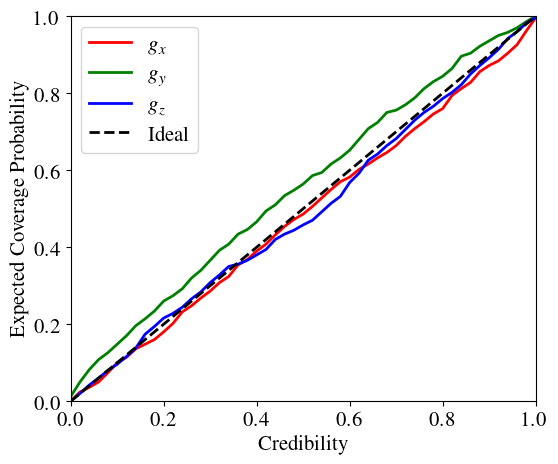

Saved output/tarp_ecp_dipole.pdf


In [ ]:
dipole_idx_tarp = np.array([0, lmax_sig, lmax_sig + 1])

# extract_g_tarp, extract_g_theta, marginal_coverage now imported from sbi_hpm.diagnostics

print('Extracting gx,gy,gz from TARP samples...')
samples_g = extract_g_tarp(samples_tarp_full.numpy())
theta_g   = extract_g_theta(theta_tarp_full.numpy())

# ── Plot 1: marginal coverage per dipole component ───────────────────────────
plt.figure(figsize=(6, 5))
colors  = ['red', 'green', 'blue']
g_names = ['$g_x$', '$g_y$', '$g_z$']
for k, (name, color) in enumerate(zip(g_names, colors)):
    alphas, ecp_k = marginal_coverage(samples_g[:, :, k], theta_g[:, k])
    plt.plot(alphas, ecp_k, color=color, linewidth=2, label=name)
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Ideal')
plt.xlabel('Credibility', fontsize=15)
plt.ylabel('Expected Coverage Probability', fontsize=15)
plt.tick_params(labelsize=15)
#plt.title('Marginal coverage - dipole (gx, gy, gz)', fontsize=13)
plt.xlim(0, 1); plt.ylim(0, 1)
plt.legend(fontsize=15)
import os; os.makedirs('output', exist_ok=True)
#plt.savefig('output/tarp_ecp_dipole.pdf', bbox_inches='tight')
plt.show()
print('Saved output/tarp_ecp_dipole.pdf')


## 11. Plots

In [22]:
# ── Corner plot: full parameter space ────────────────────────────────────────
# Split into two panels: alm (ell<=lmax_sig) and Cl(4-10)
import math

# --- Parameter labels ---
alm_labels = []
for l in range(1, lmax_sig + 1):
    alm_labels.append(rf'$E_{{ {l},0 }}$')
    for m in range(1, l + 1):
        alm_labels.append(rf'$E_{{ {l},{m} }}^R$')
        alm_labels.append(rf'$E_{{ {l},{m} }}^I$')
for l in range(1, lmax_sig + 1):
    alm_labels.append(rf'$B_{{ {l},0 }}$')
    for m in range(1, l + 1):
        alm_labels.append(rf'$B_{{ {l},{m} }}^R$')
        alm_labels.append(rf'$B_{{ {l},{m} }}^I$')

cl_labels_E = [rf'$\hat{{C}}_{{{l}}}^E$' for l in range(lmax_sig + 1, lmax_fit + 1)]
cl_labels_B = [rf'$\hat{{C}}_{{{l}}}^B$' for l in range(lmax_sig + 1, lmax_fit + 1)]
cl_labels = cl_labels_E + cl_labels_B

# --- Panel 1: alm parameters ---
fig1 = corner.corner(
    samples_full_np[:, :n_alm_l3]*1e3,
    labels=alm_labels,
    show_titles=True,
    color='steelblue',
    plot_datapoints=False,
    fill_contours=True,
    plot_contours=True,
    levels=[0.68, 0.95],
    smooth=1.5,
    title_kwargs={'fontsize': 15},
    label_kwargs={'fontsize': 15},
)
for ax in fig1.axes:
    ax.tick_params(labelsize=15)
#fig1.suptitle(r'Full model — $a_{\ell m}$ parameters ($\ell \leq$' + f'{lmax_sig})', fontsize=13, y=1.01)
plt.savefig('output/corner_full_alm.pdf', bbox_inches='tight')
plt.show()
print('Saved output/corner_full_alm.pdf')

# --- Panel 2: Cl parameters ---
fig2 = corner.corner(
    samples_full_np[:, n_alm_l3:] * 1e6,   # convert to uas^2/yr^2
    labels=cl_labels,
    show_titles=True,
    color='steelblue',
    plot_datapoints=False,
    fill_contours=True,
    plot_contours=True,
    levels=[0.68, 0.95],
    smooth=1.5,
    title_kwargs={'fontsize': 15},
    label_kwargs={'fontsize': 15},
)
for ax in fig2.axes:
    ax.tick_params(labelsize=15)
#fig2.suptitle(r'Full model — $\hat{C}_\ell$ parameters ($\ell = $' + f'{lmax_sig+1}..{lmax_fit})' + r' ($\mu$as$^2$ yr$^{-2}$)', fontsize=13, y=1.01)
plt.savefig('output/corner_full_cl.pdf', bbox_inches='tight')
plt.show()
print('Saved output/corner_full_cl.pdf')

KeyboardInterrupt: 

Drawing 500 posterior samples:  19%|█▉        | 94/500 [00:39<02:50,  2.38it/s] 


Error in callback <function flush_figures at 0x7fd08de6b1a0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
#plot the corner plot of full parameter space

In [ ]:
# ── Bootstrap: parametric noise resampling ───────────────────────────────────
# Reconstruct the best-fit ℓ≤3 signal maps from the VSH fit to real data
E_sig_best, B_sig_best = real_to_complex_alm(best_fit_l3, lmax_sig)
m_theta_sig, m_phi_sig = hp.alm2map_spin(
    [E_sig_best, B_sig_best], nside, spin=1, lmax=lmax_sig
)
pmra_signal  =  m_phi_sig
pmdec_signal = -m_theta_sig

N_bootstrap = 10000

g_boot_list = []
for _ in range(N_bootstrap):
    noise_ra, noise_dec = generate_pixel_noise()
    theta_b = solve_fast(pmra_signal + noise_ra, pmdec_signal + noise_dec, lmax=lmax_sig)
    g_boot_list.append(skyfunc.s2g(theta_b[dipole_idx] * 1e3))

g_boot = np.array(g_boot_list)   # shape (N_bootstrap, 3)
print(f"g_boot shape: {g_boot.shape}")
for k, name in enumerate(["gx", "gy", "gz"]):
    q16, q50, q84 = np.percentile(g_boot[:, k], [16, 50, 84])
    print(f"  {name}: {q50:.2f} +{q84-q50:.2f} -{q50-q16:.2f} µas/yr")


g_boot shape: (10000, 3)
  gx: -0.28 +0.40 -0.40 µas/yr
  gy: -4.26 +0.36 -0.35 µas/yr
  gz: -2.81 +0.35 -0.34 µas/yr


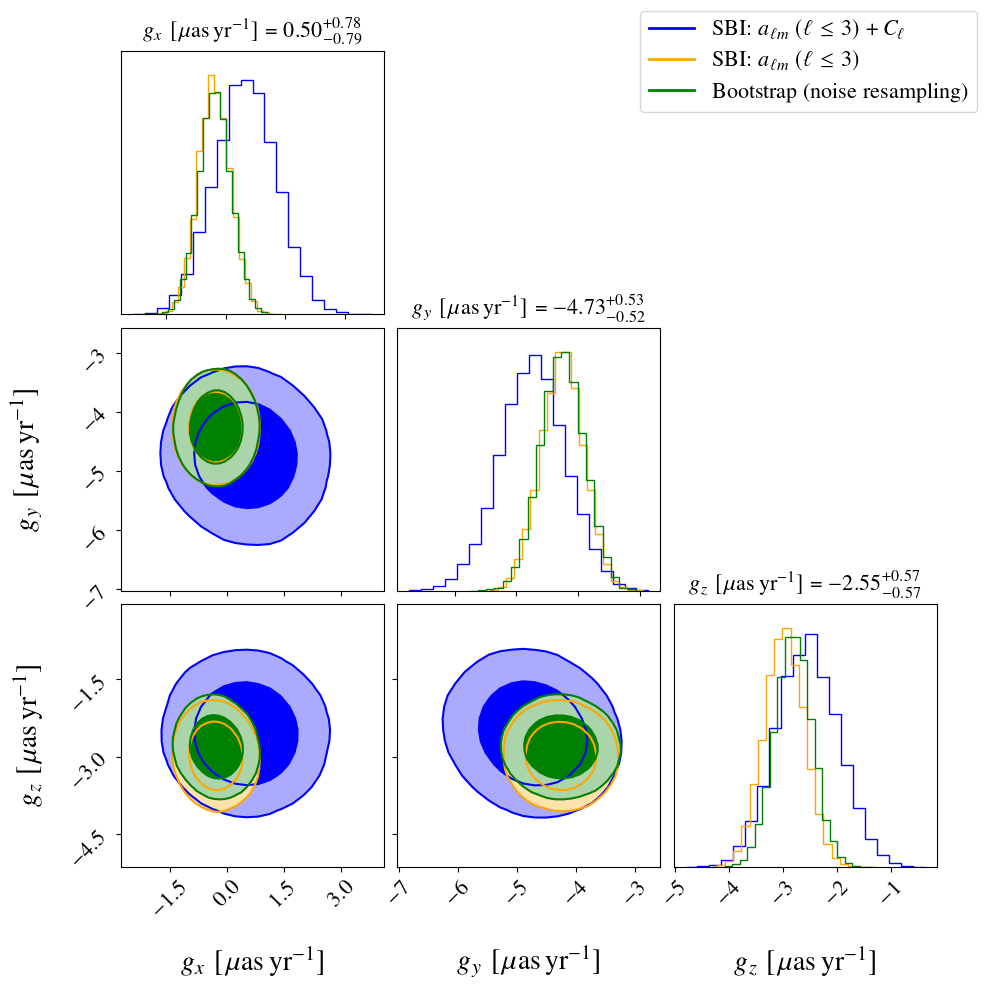

In [ ]:
# ── Corner plot: Bootstrap vs SBI posteriors ─────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

corner_kw = dict(
    labels=[r'$g_x\ [\mu\mathrm{as\,yr}^{-1}]$',
             r'$g_y\ [\mu\mathrm{as\,yr}^{-1}]$',
             r'$g_z\ [\mu\mathrm{as\,yr}^{-1}]$'],
    fig=fig,
    plot_datapoints=False,
    fill_contours=True,
    plot_contours=True,
    levels=[0.68, 0.95],
    smooth=1.5,
    hist2d_kwargs={'bins': 80, 'density': True},
    label_kwargs={'fontsize': 20},
)

corner.corner(g_full,  color='blue',   show_titles=True,
              title_kwargs={'fontsize': 16, 'pad': 10}, **corner_kw)
corner.corner(g_det,   color='orange', **corner_kw)
corner.corner(g_boot,  color='green',  **corner_kw)

for ax in fig.axes:
    ax.tick_params(labelsize=16)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue',   lw=2,
           label=r'SBI: $a_{\ell m}\,(\ell\leq 3)+C_\ell$'),
    Line2D([0], [0], color='orange', lw=2,
           label=r'SBI: $a_{\ell m}\,(\ell\leq 3)$'),
    Line2D([0], [0], color='green',  lw=2,
           label=r'Bootstrap (noise resampling)'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=16)
#plt.savefig('output/gxyz_corner_gaia_galcut_20_bootstrap_vs_sbi.pdf', bbox_inches='tight')
plt.show()

In [ ]:
np.savez('output/gxyz_posterior_samples_quaia.npz', g_full=g_full, g_det=g_det, g_boot=g_boot)

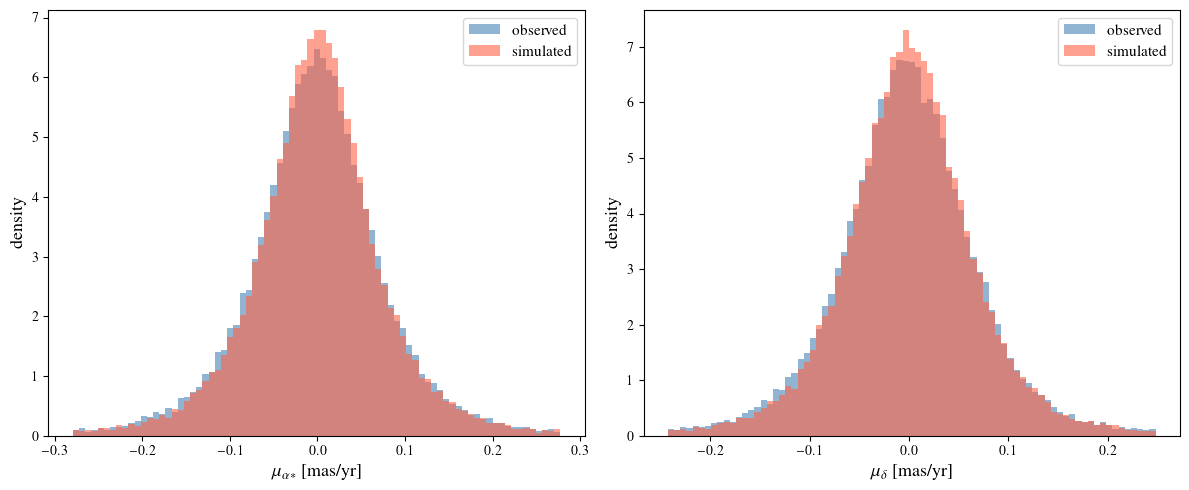

In [ ]:
median_theta = np.median(samples_full_np, axis=0)
Cl_E_fid = median_theta[n_alm_l3 : n_alm_l3 + n_Cl // 2]
Cl_B_fid = median_theta[n_alm_l3 + n_Cl // 2 :]

Cl_E_full = np.zeros(lmax_fit + 1)
Cl_B_full = np.zeros(lmax_fit + 1)
Cl_E_full[4:11] = np.maximum(Cl_E_fid, 0)
Cl_B_full[4:11] = np.maximum(Cl_B_fid, 0)

alm_E_sig = hp.synalm(Cl_E_full, lmax=lmax_fit)
alm_B_sig = hp.synalm(Cl_B_full, lmax=lmax_fit)
m_theta, m_phi = hp.alm2map_spin([alm_E_sig, alm_B_sig], nside, spin=1, lmax=lmax_fit)
pmra_sig  =  m_phi
pmdec_sig = -m_theta

noise_ra, noise_dec = generate_pixel_noise()
pmra_sim_obs  = pmra_sig  + noise_ra
pmdec_sim_obs = pmdec_sig + noise_dec

# ── Compare histograms over valid pixels ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, obs_map, sim_map, xlabel in [
    (axes[0], quaia_pmra_wm[valid_pix],  pmra_sim_obs[valid_pix],
     r'$\mu_{\alpha*}$ [mas/yr]'),
    (axes[1], quaia_pmdec_wm[valid_pix], pmdec_sim_obs[valid_pix],
     r'$\mu_{\delta}$ [mas/yr]'),
]:
    lo = np.percentile(obs_map, 1)
    hi = np.percentile(obs_map, 99)
    bins = np.linspace(lo, hi, 80)
    ax.hist(obs_map, bins=bins, density=True, alpha=0.6,
            color='steelblue', label='observed')
    ax.hist(sim_map, bins=bins, density=True, alpha=0.6,
            color='tomato',    label='simulated')
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel('density', fontsize=13)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
print(samples_full_np.shape)
print(n_alm_l3, n_Cl, n_theta)


(10000, 32)
16 16 32


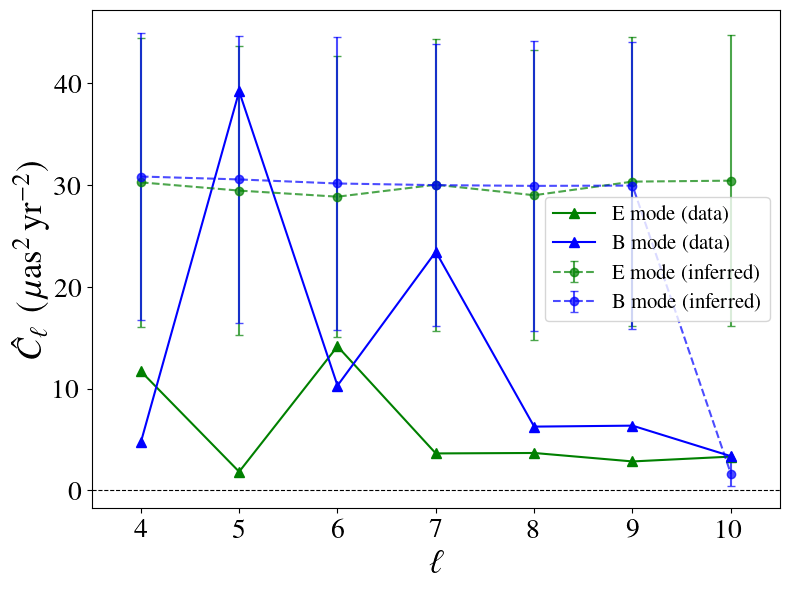

Saved output/cl_inferred_vs_data.pdf


In [ ]:
# ── Inferred Cl vs measured auto spectrum (ell=3-10) ─────────────────────────
n_Cl_half = (n_theta - n_alm_l3) // 2          # 8 (E) or 7, derived from actual shape
lmin_cl   = lmax_sig + 1                        # first stochastic ell
ells_cl   = np.arange(lmin_cl, lmax_fit + 1)   # e.g. 3..10 or 4..10

Cl_E_samples = samples_full_np[:, n_alm_l3 : n_alm_l3 + n_Cl_half]
Cl_B_samples = samples_full_np[:, n_alm_l3 + n_Cl_half :]
scale = 1e6   # (mas/yr)^2 -> (µas/yr)^2

Cl_E_med = np.median(Cl_E_samples, axis=0) * scale
Cl_B_med = np.median(Cl_B_samples, axis=0) * scale
Cl_E_err = np.std(Cl_E_samples, axis=0) * scale
Cl_B_err = np.std(Cl_B_samples, axis=0) * scale

# Measured auto spectrum from data pixels (healpy, mask-corrected)
mask_hp = mask_quaia.astype(float)
f_sky   = np.mean(mask_hp ** 2)
alm_E_d, alm_B_d = hp.map2alm_spin(
    [-quaia_pmdec_wm * mask_hp, quaia_pmra_wm * mask_hp],
    spin=1, lmax=lmax_fit
)
cl_data_EE = hp.alm2cl(alm_E_d) / f_sky * scale
cl_data_BB = hp.alm2cl(alm_B_d) / f_sky * scale
cl_data_E  = cl_data_EE[lmin_cl : lmax_fit + 1]
cl_data_B  = cl_data_BB[lmin_cl : lmax_fit + 1]

plt.figure(figsize=(8, 6))
plt.errorbar(ells_cl, Cl_E_med, yerr=Cl_E_err,
             fmt='go--', capsize=3, label='E mode (inferred)', alpha=0.7)
plt.errorbar(ells_cl, Cl_B_med, yerr=Cl_B_err,
             fmt='bo--', capsize=3, label='B mode (inferred)', alpha=0.7)
plt.plot(ells_cl, cl_data_E, 'g^-', markersize=7, linewidth=1.5, label='E mode (data)')
plt.plot(ells_cl, cl_data_B, 'b^-', markersize=7, linewidth=1.5, label='B mode (data)')
plt.axhline(0, color='k', linewidth=0.8, linestyle='--')
plt.xlabel(r'$\rm \ell$', fontsize=25)
plt.ylabel(r'$\hat{C}_{\rm \ell}\,\,(\mu\mathrm{as}^2\,\mathrm{yr}^{-2})$', fontsize=25)
plt.legend(fontsize=15)
plt.xlim(lmin_cl - 0.5, lmax_fit + 0.5)
plt.xticks(np.arange(lmin_cl, lmax_fit + 1, 1), fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig('output/cl_inferred_vs_data.pdf', bbox_inches='tight')
plt.show()
print('Saved output/cl_inferred_vs_data.pdf')

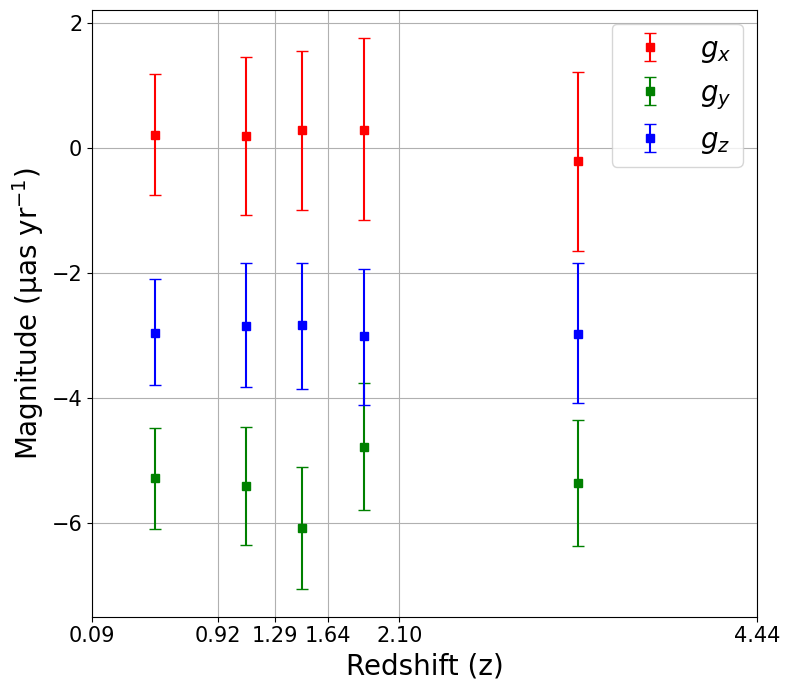

In [ ]:
z_centers = 0.5 * (z_bin_edges[:-1] + z_bin_edges[1:])
z_widths  = 0.5 * (z_bin_edges[1:]  - z_bin_edges[:-1])

gx = [0.21, 0.20, 0.29, 0.30, -0.21]
gy = [-5.28, -5.40, -6.08, -4.78, -5.36]
gz = [-2.95, -2.84, -2.83, -3.00, -2.97]

gx_err = np.array([[0.96, 1.26, 1.28, 1.44, 1.44],
                   [0.97, 1.26, 1.27, 1.47, 1.43]])
gy_err = np.array([[0.81, 0.94, 0.97, 1.00, 1.00],
                   [0.81, 0.95, 0.98, 1.02, 1.02]])
gz_err = np.array([[0.83, 0.98, 1.02, 1.10, 1.10],
                   [0.86, 1.00, 1.00, 1.07, 1.13]])

colors_g = ['red', 'green', 'blue']

fig, ax = plt.subplots(figsize=(8, 7))

ax.errorbar(z_centers, gx, yerr=gx_err,
            fmt='s', color=colors_g[0], capsize=4, lw=1.5, markersize=6,
            label=r'$g_x$')
ax.errorbar(z_centers, gy, yerr=gy_err,
            fmt='s', color=colors_g[1], capsize=4, lw=1.5, markersize=6,
            label=r'$g_y$')
ax.errorbar(z_centers, gz, yerr=gz_err, 
            fmt='s', color=colors_g[2], capsize=4, lw=1.5, markersize=6,
            label=r'$g_z$')

ax.set_xlabel('Redshift (z)', fontsize=20)
ax.set_ylabel(r'Magnitude (µas yr$^{-1}$)', fontsize=20)
ax.tick_params(labelsize=15)
ax.legend(fontsize=20)

# X-ticks at bin edges only, data points sit at bin centres
ax.set_xticks(z_bin_edges)
ax.set_xticklabels([f'{z:.2f}' for z in z_bin_edges], fontsize=15)

plt.tight_layout()
plt.grid('on')
plt.savefig('output/gxyz_vs_z_quaia.pdf', bbox_inches='tight')
plt.show()


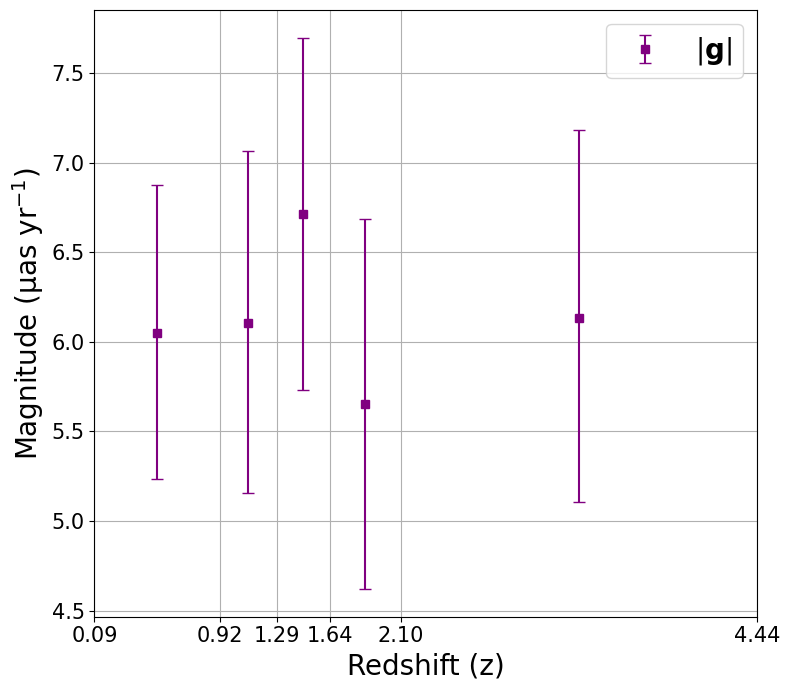

In [ ]:
g_mag = [np.sqrt(gx[i]**2 + gy[i]**2 + gz[i]**2) for i in range(5)]

# Propagate asymmetric errors: |g| uncertainty via quadrature
g_mag_lo, g_mag_hi = [], []
for i in range(5):
    gx_lo, gy_lo, gz_lo = gx_err[0, i], gy_err[0, i], gz_err[0, i]
    gx_hi, gy_hi, gz_hi = gx_err[1, i], gy_err[1, i], gz_err[1, i]
    g_mag_lo.append(np.sqrt(gx[i]**2 * gx_lo**2 + gy[i]**2 * gy_lo**2 + gz[i]**2 * gz_lo**2) / g_mag[i])
    g_mag_hi.append(np.sqrt(gx[i]**2 * gx_hi**2 + gy[i]**2 * gy_hi**2 + gz[i]**2 * gz_hi**2) / g_mag[i])

g_mag_err = np.array([g_mag_lo, g_mag_hi])

fig, ax = plt.subplots(figsize=(8, 7))

ax.errorbar(z_centers, g_mag, yerr=g_mag_err,
            fmt='s', color='purple', capsize=4, lw=1.5, markersize=6,
            label=r'$|\mathbf{g}|$')

ax.set_xlabel('Redshift (z)', fontsize=20)
ax.set_ylabel(r'Magnitude (µas yr$^{-1}$)', fontsize=20)
ax.tick_params(labelsize=15)
ax.legend(fontsize=20)

ax.set_xticks(z_bin_edges)
ax.set_xticklabels([f'{z:.2f}' for z in z_bin_edges], fontsize=15)

plt.tight_layout()
plt.grid('on')
plt.savefig('output/gmag_vs_z_quaia.pdf', bbox_inches='tight')
plt.show()


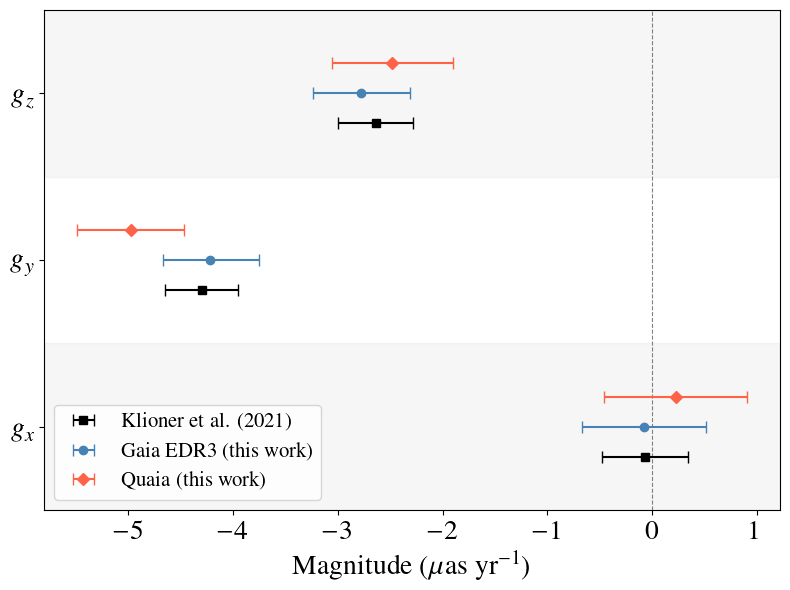

In [ ]:
klioner = {
    'gx': (-0.07, 0.41, 0.41),
    'gy': (-4.30, 0.35, 0.35),
    'gz': (-2.64, 0.36, 0.36),
}

# Your Gaia EDR3 Model 2 (unmasked)
gaia = {
    'gx': (-0.08, 0.59, 0.59),
    'gy': (-4.22, 0.47, 0.45),
    'gz': (-2.78, 0.47, 0.46),
}

# Your Quaia Model 2
quaia = {
    'gx': (0.23, 0.67, 0.69),
    'gy': (-4.98, 0.51, 0.51),
    'gz': (-2.48, 0.58, 0.58),
}

# Three sources, vertical offsets within each subplot for separation
sources = [klioner, gaia, quaia]
source_labels = ['Klioner et al. (2021)', 'Gaia EDR3 (this work)', 'Quaia (this work)']
colors = ['black', 'steelblue', 'tomato']
markers = ['s', 'o', 'D']

components = ['gx', 'gy', 'gz']
comp_labels = [r'$g_x$', r'$g_y$', r'$g_z$']

# Each component gets a base y position (0, 1, 2)
# Each source gets a small offset within the group
group_spacing = 1.0   # space between component groups
point_spacing = 0.18  # space between sources within a group
offsets = [-point_spacing, 0, point_spacing]

# Base y positions for each component group
base_positions = np.arange(len(components)) * group_spacing

fig, ax = plt.subplots(figsize=(8, 6))

for i, (src, src_label, color, marker, offset) in enumerate(
    zip(sources, source_labels, colors, markers, offsets)
):
    y_positions = base_positions + offset
    vals = [src[c][0] for c in components]
    errs_lo = [src[c][2] for c in components]
    errs_up = [src[c][1] for c in components]

    ax.errorbar(
        vals, y_positions,
        xerr=[errs_lo, errs_up],
        fmt=marker,
        color=color,
        markersize=6,
        capsize=4,
        linewidth=1.5,
        label=src_label,
        zorder=3
    )

# Horizontal line at zero
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, zorder=1)

# Light horizontal bands to separate component groups
for i, base in enumerate(base_positions):
    if i % 2 == 0:
        ax.axhspan(
            base - group_spacing / 2,
            base + group_spacing / 2,
            color='lightgray', alpha=0.2, zorder=0
        )

# Y axis labels at base positions
ax.set_yticks(base_positions)
ax.set_yticklabels(comp_labels, fontsize=20)

ax.set_xlabel(r'Magnitude ($\mu$as yr$^{-1}$)', fontsize=20)
ax.tick_params(axis='x', labelsize=20)

ax.legend(
    fontsize=15,
    frameon=True,
    loc='lower left'
)

ax.set_ylim(-0.5 * group_spacing, (len(components) - 0.5) * group_spacing)


plt.tight_layout()
plt.savefig('output/acceleration_comparison.pdf', bbox_inches='tight')
plt.show()

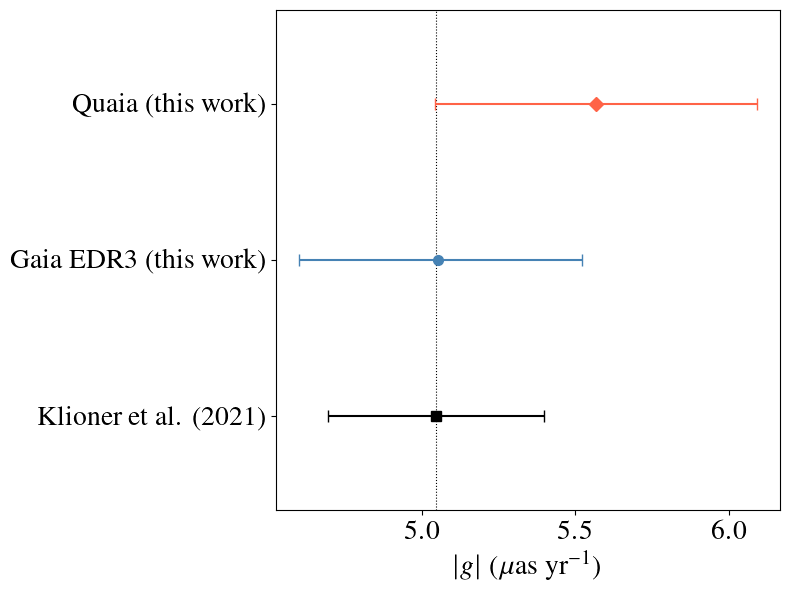

In [ ]:
def compute_magnitude(src):
    """Compute |g| and propagate errors."""
    gx, ex_up, ex_lo = src['gx']
    gy, ey_up, ey_lo = src['gy']
    gz, ez_up, ez_lo = src['gz']
    
    mag = np.sqrt(gx**2 + gy**2 + gz**2)
    
    # Error propagation: sigma_|g| = sqrt((gx*sx)^2 + (gy*sy)^2 + (gz*sz)^2) / |g|
    err_up = np.sqrt(
        (gx * ex_up)**2 + (gy * ey_up)**2 + (gz * ez_up)**2
    ) / mag
    err_lo = np.sqrt(
        (gx * ex_lo)**2 + (gy * ey_lo)**2 + (gz * ez_lo)**2
    ) / mag
    
    return mag, err_up, err_lo 

magnitudes = [compute_magnitude(src) for src in sources]

# y positions: one per source, spread vertically
y_positions = np.arange(len(sources)) * 0.5

fig2, ax2 = plt.subplots(figsize=(8, 6))

for i, (mag_data, src_label, color, marker) in enumerate(
    zip(magnitudes, source_labels, colors, markers)
):
    mag, err_up, err_lo = mag_data
    ax2.errorbar(
        mag, y_positions[i],
        xerr=[[err_lo], [err_up]],
        fmt=marker,
        color=color,
        markersize=7,
        capsize=4,
        linewidth=1.5,
        label=src_label,
        zorder=3
    )

# Reference value from Klioner 2021
ax2.axvline(
    magnitudes[0][0],
    color='black',
    linestyle=':',
    linewidth=0.8,
    zorder=1,
    label=None
)

ax2.set_yticks(y_positions)
ax2.set_yticklabels(source_labels, fontsize=20)
ax2.set_xlabel(r'$|g|$ ($\mu$as yr$^{-1}$)', fontsize=20)
ax2.tick_params(axis='x', labelsize=20)
ax2.set_ylim(-0.3, y_positions[-1] + 0.3)

plt.tight_layout()
plt.savefig('acceleration_magnitude_comparison.pdf', bbox_inches='tight')
plt.show()

In [ ]:


N_INDIV = 100    # simulations to show in histogram overlay
N_PPC   = 1000   # simulations for variance distribution

rng = np.random.default_rng(42)
idx_ppc = rng.choice(len(samples_full_np), size=N_PPC, replace=False)

pmra_indiv   = []   # full pixel arrays for first N_INDIV (pmra_obs)
pmdec_indiv  = []
pmra_cl_list = []   # Cl(4-10) noise maps for first N_INDIV
pmdec_cl_list= []

var_pmra_sims  = np.zeros(N_PPC)
var_pmdec_sims = np.zeros(N_PPC)

print(f"Running {N_PPC} posterior predictive simulations ...")
for k, idx in enumerate(idx_ppc):
    theta_i = torch.tensor(samples_full_np[idx], dtype=torch.float32)
    _, pmra_obs_i, pmdec_obs_i, pmra_cl_i, pmdec_cl_i, pmra_noise_i, pmdec_noise_i = simulator_full(theta_i)

    pmra_i  = np.asarray(pmra_obs_i)
    pmdec_i = np.asarray(pmdec_obs_i)

    var_pmra_sims[k]  = np.var(pmra_i [mask_quaia])
    var_pmdec_sims[k] = np.var(pmdec_i[mask_quaia])

    if k < N_INDIV:
        pmra_indiv.append(pmra_i[mask_quaia]  * 1e3)   # mas/yr -> uas/yr
        pmdec_indiv.append(pmdec_i[mask_quaia] * 1e3)
        pmra_cl_list.append(np.asarray(pmra_noise_i) [mask_quaia] * 1e3)
        pmdec_cl_list.append(np.asarray(pmdec_noise_i)[mask_quaia] * 1e3)

    if (k + 1) % 50 == 0:
        print(f"  {k+1}/{N_PPC}")

print("Done.")

# ── data quantities ──────────────────────────────────────────────────────────
pmra_data  = quaia_pmra_wm [mask_quaia] * 1e3   # uas/yr
pmdec_data = quaia_pmdec_wm[mask_quaia] * 1e3

sig_pmra_data  = quaia_sig_pmra_wm [mask_quaia] * 1e3   # per-pixel sigma, uas/yr
sig_pmdec_data = quaia_sig_pmdec_wm[mask_quaia] * 1e3

var_pmra_data  = np.var(quaia_pmra_wm [mask_quaia]) * 1e6   # uas^2/yr^2
var_pmdec_data = np.var(quaia_pmdec_wm[mask_quaia]) * 1e6

var_pmra_sims_scaled  = var_pmra_sims  * 1e6
var_pmdec_sims_scaled = var_pmdec_sims * 1e6

# ── Figure 1: mu_obs histograms -- individual simulations vs data ─────────────
with plt.rc_context({'text.usetex': True}):
    fig1, axes1 = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    bins = 60
    for ax, indiv_list, data_arr, label in zip(
            axes1,
            [pmra_indiv,  pmdec_indiv],
            [pmra_data,   pmdec_data],
            [r'$\mu_{\alpha*}$', r'$\mu_\delta$']):

        for sim_arr in indiv_list:
            ax.hist(sim_arr, bins=bins, density=True,
                    color='grey', alpha=0.25, linewidth=0.8, histtype='step')

        ax.hist(data_arr, bins=bins, density=True,
                color='red', linewidth=1.8, histtype='step', label='Data')

        ax.set_xlabel(label + r' ($\mu$as yr$^{-1}$)')
        ax.set_ylabel('Probability density' if ax is axes1[0] else '')
        ax.legend(fontsize=10)

    # fig1.suptitle(r'PPC: pixel proper-motion distributions'
    #               r' (grey = 30 posterior draws, red = data)')
    plt.show()

# ── Figure 2: Cl(4-10) noise map histograms vs per-pixel sigma from data ─────
with plt.rc_context({'text.usetex': True}):
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    bins2 = 60
    for ax, cl_list, sig_data, label in zip(
            axes2,
            [pmra_cl_list,  pmdec_cl_list],
            [sig_pmra_data, sig_pmdec_data],
            [r'$\mu_{\alpha*}$', r'$\mu_\delta$']):

        for cl_arr in cl_list:
            ax.hist(cl_arr, bins=bins2, density=False,
                    color='steelblue', alpha=0.20, linewidth=0.8, histtype='step')

        # Per-pixel noise sigma from data (as reference scale)
        # ax.axvline( np.mean(sig_data), color='red', linestyle='--', linewidth=1.8,
        #            label=r'Mean $\sigma_{\rm pixel}$ (data)')
        # ax.axvline(-np.mean(sig_data), color='red', linestyle='--', linewidth=1.8)
        ax.hist(sig_data, bins=bins2, density=False,
                color='tomato', alpha=1, linewidth=1.5, histtype='step', label='Data per-pixel $\sigma$')

        ax.set_xlabel(r'$C_{\ell}$ noise + pixel noise ' + label + r' ($\mu$as yr$^{-1}$)')
        ax.set_ylabel('Probability density' if ax is axes2[0] else '')
        ax.legend(fontsize=10)

    # fig2.suptitle(r'$C_\ell(4\!-\!10)$ noise maps (blue = 30 draws)'
    #               r' vs.\ per-pixel $\sigma$ scale (red)')
    plt.show()

# ── Figure 3: var(mu_sim) distribution vs var(mu_data) ───────────────────────
with plt.rc_context({'text.usetex': True}):
    fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    for ax, var_sims, var_data, label in zip(
            axes3,
            [var_pmra_sims_scaled,  var_pmdec_sims_scaled],
            [var_pmra_data,          var_pmdec_data],
            [r'$\mu_{\alpha*}$',     r'$\mu_\delta$']):

        p_val = np.mean(var_sims >= var_data)

        ax.hist(var_sims, bins=40, color='steelblue', alpha=0.7,
                label=r'Posterior draws ($N={:d}$)'.format(N_PPC))
        ax.axvline(var_data, color='red', linestyle='--', linewidth=1.8,
                   label='Data')
        ax.set_xlabel(r'Var(' + label[1:-1] + r') ($\mu$as$^{2}$ yr$^{-2}$)')
        ax.set_ylabel('Count' if ax is axes3[0] else '')
        ax.set_title(r'$p$-value $= {:.3f}$'.format(p_val))
        ax.legend(fontsize=10)

    # fig3.suptitle(r'PPC: spatial variance of proper-motion maps')
    plt.show()

# ── quick summary ────────────────────────────────────────────────────────────
p_ra  = np.mean(var_pmra_sims_scaled  >= var_pmra_data)
p_dec = np.mean(var_pmdec_sims_scaled >= var_pmdec_data)
print(f"Variance p-values:  mu_ra = {p_ra:.3f}   mu_dec = {p_dec:.3f}")
if p_ra > 0.05 and p_dec > 0.05:
    print("PASS: noise variance is well-calibrated (data within simulation envelope).")
else:
    print("FLAG: data variance is an outlier -- possible noise mis-calibration.")


Running 1000 posterior predictive simulations ...


<>:96: SyntaxWarning: invalid escape sequence '\s'
<>:96: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6163/425928829.py:96: SyntaxWarning: invalid escape sequence '\s'
  color='tomato', alpha=1, linewidth=1.5, histtype='step', label='Data per-pixel $\sigma$')
/tmp/ipykernel_6163/425928829.py:96: SyntaxWarning: invalid escape sequence '\s'
  color='tomato', alpha=1, linewidth=1.5, histtype='step', label='Data per-pixel $\sigma$')


ValueError: not enough values to unpack (expected 7, got 5)